1. Install library

In [ ]:
!pip install tensorflow matplotlib seaborn scikit-learn pillow

2. Import library

In [ ]:
import tensorflow as tf
import numpy as np
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

from sklearn.metrics import classification_report, confusion_matrix

3. Google Drive

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


4. Menentukan path dataset

In [ ]:
dataset_dir = "/content/drive/MyDrive/BatikAI/Dataset/raw_batik_v2.1"

- Cek folder dataset


In [ ]:
print(os.listdir(dataset_dir))

['train', 'test']


5. Data Generator

In [ ]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32


train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)


test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

6. Load Data Generator ( EDA )

In [ ]:
train_path = os.path.join(dataset_dir,"train")
test_path = os.path.join(dataset_dir,"test")


train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)


val_data = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)


test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 520 images belonging to 20 classes.
Found 120 images belonging to 20 classes.
Found 160 images belonging to 20 classes.


7. Nama Kelas

In [ ]:
class_names = list(train_data.class_indices.keys())

print(class_names)

print("Jumlah kelas :",len(class_names))

['Aceh_Pintu_Aceh', 'Bali_Barong', 'Bali_Merak', 'DKI_Ondel_Ondel', 'JawaBarat_Megamendung', 'JawaTimur_Pring', 'Kalimantan_Dayak', 'Lampung_Gajah', 'Madura_Mataketeran', 'Maluku_Pala', 'NTB_Lumbung', 'Papua_Asmat', 'Papua_Cendrawasih', 'Papua_Tifa', 'Solo_Parang', 'SulawesiSelatan_Lontara', 'SumateraBarat_Rumah_Minang', 'SumateraUtara_Boraspati', 'Yogyakarta_Kawung', 'Yogyakarta_Parang']
Jumlah kelas : 20


8. Model Tranfer Learning ( MobilNet12 )

In [ ]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)


base_model.trainable=False


x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation="relu"
)(x)


x = Dropout(0.4)(x)


output = Dense(
    len(class_names),
    activation="softmax"
)(x)


model = Model(
    inputs=base_model.input,
    outputs=output
)


model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,591,060 (9.88 MB)

 Trainable params: 333,076 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

9. Compile model

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy"
    ]
)

10. Training

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 405s 23s/step - accuracy: 0.0423 - loss: 3.4954 - val_accuracy: 0.1667 - val_loss: 2.8795
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 630ms/step - accuracy: 0.1385 - loss: 2.9122 - val_accuracy: 0.2333 - val_loss: 2.5938
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 559ms/step - accuracy: 0.1942 - loss: 2.7208 - val_accuracy: 0.3250 - val_loss: 2.4079
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 580ms/step - accuracy: 0.2769 - loss: 2.4542 - val_accuracy: 0.3583 - val_loss: 2.2570
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 633ms/step - accuracy: 0.3269 - loss: 2.2481 - val_accuracy: 0.4167 - val_loss: 2.1524
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 609ms/step - accuracy: 0.3615 - loss: 2.0992 - val_accuracy: 0.5000 - val_loss: 1.9893
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 533ms/step - accuracy: 0.4058 - loss: 2.0021 - val_accuracy: 0.4917 - val_loss: 1.9384
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 641ms/step - accuracy: 0.4731 - loss: 1.8009 - val_accurac

11. Grafik Training

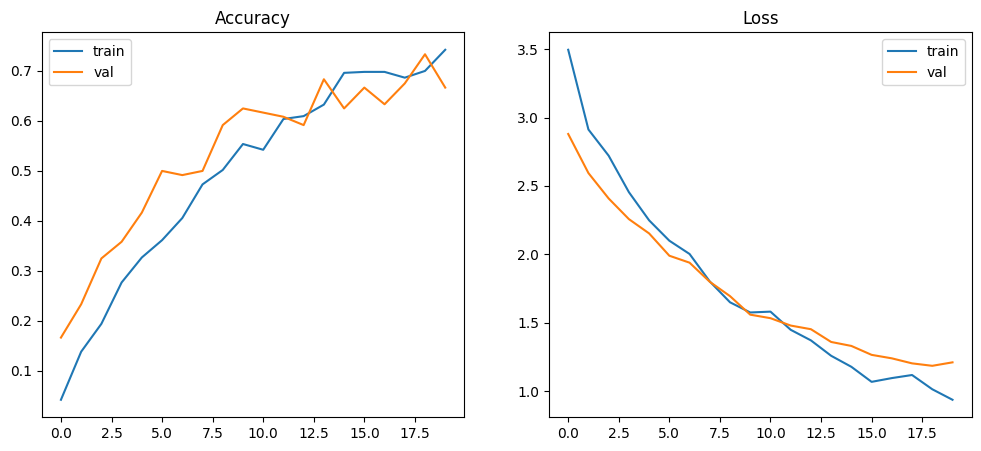

In [ ]:
plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.legend(["train","val"])



plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.legend(["train","val"])


plt.show()

12. Evaluasi Test

In [ ]:
loss,acc = model.evaluate(test_data)

print(
"Test Accuracy:",
acc
)

5/5 ━━━━━━━━━━━━━━━━━━━━ 64s 16s/step - accuracy: 0.7125 - loss: 1.0863
Test Accuracy: 0.7124999761581421


13. Classification Report

In [ ]:
pred = model.predict(test_data)

pred_class = np.argmax(
    pred,
    axis=1
)


print(
classification_report(
    test_data.classes,
    pred_class,
    target_names=class_names
)
)

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step
                            precision    recall  f1-score   support

           Aceh_Pintu_Aceh       0.50      0.50      0.50         8
               Bali_Barong       0.70      0.88      0.78         8
                Bali_Merak       0.73      1.00      0.84         8
           DKI_Ondel_Ondel       0.75      0.75      0.75         8
     JawaBarat_Megamendung       0.88      0.88      0.88         8
           JawaTimur_Pring       0.83      0.62      0.71         8
          Kalimantan_Dayak       0.80      1.00      0.89         8
             Lampung_Gajah       0.78      0.88      0.82         8
        Madura_Mataketeran       0.86      0.75      0.80         8
               Maluku_Pala       1.00      0.62      0.77         8
               NTB_Lumbung       0.29      0.25      0.27         8
               Papua_Asmat       0.50      0.38      0.43         8
         Papua_Cendrawasih       1.00      0.62      0.77         8
        

14. Model untuk VS Code

In [ ]:
save_path = "/content/drive/MyDrive/BatikAI/batik_model_final.keras"


model.save(save_path)


print(
"Model berhasil disimpan"
)

Model berhasil disimpan


15. Testing di Colab

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 0015.jpg to 0015.jpg


In [ ]:
from PIL import Image


img_path=list(uploaded.keys())[0]


img = Image.open(img_path).convert("RGB")


img = img.resize(
    (224,224)
)


img_array=np.array(img)


img_array=tf.keras.applications.mobilenet_v2.preprocess_input(
    img_array
)


img_array=np.expand_dims(
    img_array,
    axis=0
)



prediction=model.predict(img_array)



index=np.argmax(prediction)


print(
"Prediksi:",
class_names[index]
)


print(
"Confidence:",
prediction[0][index]*100,
"%"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Prediksi: Bali_Merak
Confidence: 27.22077 %


16. Menyimpan Clasess

In [ ]:
import json
import os

# Ambil nama kelas dari dataset
class_names = list(train_data.class_indices.keys())

print("Jumlah kelas:", len(class_names))
print("Daftar kelas:")
print(class_names)


# Lokasi penyimpanan
save_class = "/content/drive/MyDrive/BatikAI/classes.json"


# Simpan file JSON
with open(save_class, "w") as f:
    json.dump(class_names, f, indent=4)


print("\nclasses.json berhasil dibuat:")
print(save_class)

Jumlah kelas: 20
Daftar kelas:
['Aceh_Pintu_Aceh', 'Bali_Barong', 'Bali_Merak', 'DKI_Ondel_Ondel', 'JawaBarat_Megamendung', 'JawaTimur_Pring', 'Kalimantan_Dayak', 'Lampung_Gajah', 'Madura_Mataketeran', 'Maluku_Pala', 'NTB_Lumbung', 'Papua_Asmat', 'Papua_Cendrawasih', 'Papua_Tifa', 'Solo_Parang', 'SulawesiSelatan_Lontara', 'SumateraBarat_Rumah_Minang', 'SumateraUtara_Boraspati', 'Yogyakarta_Kawung', 'Yogyakarta_Parang']

classes.json berhasil dibuat:
/content/drive/MyDrive/BatikAI/classes.json


In [ ]:
with open("/content/drive/MyDrive/BatikAI/classes.json","r") as f:
    data=json.load(f)

print(data)

['Aceh_Pintu_Aceh', 'Bali_Barong', 'Bali_Merak', 'DKI_Ondel_Ondel', 'JawaBarat_Megamendung', 'JawaTimur_Pring', 'Kalimantan_Dayak', 'Lampung_Gajah', 'Madura_Mataketeran', 'Maluku_Pala', 'NTB_Lumbung', 'Papua_Asmat', 'Papua_Cendrawasih', 'Papua_Tifa', 'Solo_Parang', 'SulawesiSelatan_Lontara', 'SumateraBarat_Rumah_Minang', 'SumateraUtara_Boraspati', 'Yogyakarta_Kawung', 'Yogyakarta_Parang']


TEST LAGI

In [ ]:
import tensorflow as tf
import numpy as np
import json
from PIL import Image

# Load model yang sudah disimpan
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/BatikAI/batik_model_final.keras"
)

# Load nama kelas
with open("/content/drive/MyDrive/BatikAI/classes.json", "r") as f:
    class_names = json.load(f)

# Upload gambar
from google.colab import files
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# Buka gambar
img = Image.open(image_path).convert("RGB")
img = img.resize((224,224))

img_array = np.array(img)

# Preprocessing HARUS sama dengan saat training
img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

pred_index = np.argmax(prediction)
confidence = prediction[0][pred_index] * 100

print("Prediksi :", class_names[pred_index])
print(f"Confidence : {confidence:.2f}%")

Saving 0015.jpg to 0015 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Prediksi : Bali_Merak
Confidence : 27.22%
